In [144]:
import cv2
import numpy as np
import pywt
import random
import matplotlib.pyplot as plt

from pathlib import Path
import shutil

In [1]:
from pathlib import Path
import random
import shutil

SOURCE = Path("./cfp_flattened")
OUTPUT = Path("./cfp_split")

IMAGES_PER_PERSON = 10

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

SEED = 42

random.seed(SEED)

extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

images = sorted(
    p for p in SOURCE.iterdir()
    if p.is_file() and p.suffix.lower() in extensions
)

print(f"Found {len(images)} images")

# Make groups of 10 consecutive images.
people = []

for i in range(0, len(images), IMAGES_PER_PERSON):
    group = images[i:i + IMAGES_PER_PERSON]

    # Ignore incomplete final group
    if len(group) != IMAGES_PER_PERSON:
        print(f"Skipping incomplete group with {len(group)} images")
        continue

    # Shuffle images belonging to this person
    random.shuffle(group)

    people.append(group)

print(f"Found {len(people)} people")

# Shuffle people, NOT individual images.
random.shuffle(people)

n_people = len(people)

train_end = int(n_people * TRAIN_RATIO)
val_end = train_end + int(n_people * VAL_RATIO)

splits = {
    "train_class": people[:train_end],
    "val_class": people[train_end:val_end],
    "test_class": people[val_end:],
}

for split, person_groups in splits.items():

    print(f"\n{split}: {len(person_groups)} people")

    for person_idx, person_images in enumerate(person_groups):

        class_dir = OUTPUT / split / f"person_{person_idx:04d}"
        class_dir.mkdir(parents=True, exist_ok=True)

        for image in person_images:
            shutil.copy2(
                image,
                class_dir / image.name
            )

        print(
            f"  person_{person_idx:04d}: "
            f"{len(person_images)} images"
        )

print("\nDone!")
print(f"Output: {OUTPUT.resolve()}")

Found 2243 images
Skipping incomplete group with 3 images
Found 224 people

train_class: 179 people
  person_0000: 10 images
  person_0001: 10 images
  person_0002: 10 images
  person_0003: 10 images
  person_0004: 10 images
  person_0005: 10 images
  person_0006: 10 images
  person_0007: 10 images
  person_0008: 10 images
  person_0009: 10 images
  person_0010: 10 images
  person_0011: 10 images
  person_0012: 10 images
  person_0013: 10 images
  person_0014: 10 images
  person_0015: 10 images
  person_0016: 10 images
  person_0017: 10 images
  person_0018: 10 images
  person_0019: 10 images
  person_0020: 10 images
  person_0021: 10 images
  person_0022: 10 images
  person_0023: 10 images
  person_0024: 10 images
  person_0025: 10 images
  person_0026: 10 images
  person_0027: 10 images
  person_0028: 10 images
  person_0029: 10 images
  person_0030: 10 images
  person_0031: 10 images
  person_0032: 10 images
  person_0033: 10 images
  person_0034: 10 images
  person_0035: 10 images


In [145]:
# SOURCE_ROOT = Path("cfp-dataset/Data/Images")
# OUTPUT_DIR = Path("cfp_flattened")

# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# count = 0

# for group_dir in SOURCE_ROOT.iterdir():

#     # 001, 002, 003, ...
#     if not group_dir.is_dir():
#         continue

#     frontal_dir = group_dir / "frontal"

#     if not frontal_dir.is_dir():
#         continue

#     # Images inside frontal/
#     for image_path in frontal_dir.iterdir():

#         if not image_path.is_file():
#             continue

#         if image_path.suffix.lower() not in extensions:
#             continue

#         # Example:
#         # 001/frontal/abc.jpg
#         # -> 001_abc.jpg
#         destination = OUTPUT_DIR / f"{group_dir.name}_{image_path.name}"

#         shutil.copy2(image_path, destination)

#         count += 1

# print(f"Copied {count} images.")
# print(f"Output: {OUTPUT_DIR.resolve()}")

In [146]:
class DwtDctWatermark:
    def __init__(
        self,
        wavelet="haar",
        block_size=8,
        alpha=10.0,
        coeff1=(3, 4),
        coeff2=(4, 3),
    ):
        self.wavelet = wavelet
        self.block_size = block_size
        self.alpha = alpha
        self.coeff1 = coeff1
        self.coeff2 = coeff2

    @staticmethod
    def text_to_bits(text):
        data = text.encode("utf-8")

        bits = []

        for byte in data:
            for i in range(7, -1, -1):
                bits.append((byte >> i) & 1)

        return np.array(bits, dtype=np.uint8)

    def _embed_bit(self, block, bit):
        dct = cv2.dct(block.astype(np.float32))

        r1, c1 = self.coeff1
        r2, c2 = self.coeff2

        a = dct[r1, c1]
        b = dct[r2, c2]

        if bit == 1:
            if a <= b + self.alpha:
                dct[r1, c1] = b + self.alpha
        else:
            if b <= a + self.alpha:
                dct[r2, c2] = a + self.alpha

        return cv2.idct(dct)

    def embed_bits(self, image, bits):
        ycrcb = cv2.cvtColor(image, cv2.COLOR_BGR2YCrCb)

        y = ycrcb[:, :, 0].astype(np.float32)

        # 1-level Haar DWT
        ll, (lh, hl, hh) = pywt.dwt2(
            y,
            self.wavelet
        )

        block_size = self.block_size

        blocks_y = hl.shape[0] // block_size
        blocks_x = hl.shape[1] // block_size

        capacity = blocks_y * blocks_x

        if len(bits) > capacity:
            raise ValueError(
                f"Watermark requires {len(bits)} bits, "
                f"but this image can only hold {capacity} bits."
            )

        bit_index = 0

        for by in range(blocks_y):
            for bx in range(blocks_x):

                if bit_index >= len(bits):
                    break

                y0 = by * block_size
                x0 = bx * block_size

                block = hl[
                    y0:y0 + block_size,
                    x0:x0 + block_size
                ]

                hl[
                    y0:y0 + block_size,
                    x0:x0 + block_size
                ] = self._embed_bit(
                    block,
                    bits[bit_index]
                )

                bit_index += 1

            if bit_index >= len(bits):
                break

        # Inverse DWT
        watermarked_y = pywt.idwt2(
            (ll, (lh, hl, hh)),
            self.wavelet
        )

        watermarked_y = watermarked_y[
            :image.shape[0],
            :image.shape[1]
        ]

        ycrcb[:, :, 0] = np.clip(
            watermarked_y,
            0,
            255
        ).astype(np.uint8)

        return cv2.cvtColor(
            ycrcb,
            cv2.COLOR_YCrCb2BGR
        )

    def _extract_bit(self, block):
        dct = cv2.dct(
            block.astype(np.float32)
        )

        r1, c1 = self.coeff1
        r2, c2 = self.coeff2

        return int(
            dct[r1, c1] > dct[r2, c2]
        )


    
    def extract_bits(self, image, num_bits):
        """
        Extract a fixed number of watermark bits.
        """

        ycrcb = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2YCrCb
        )

        y = ycrcb[:, :, 0].astype(np.float32)

        # DWT returns:
        # LL, (LH, HL, HH)
        ll, (lh, hl, hh) = pywt.dwt2(
            y,
            self.wavelet
        )

        block_size = self.block_size

        blocks_y = hl.shape[0] // block_size
        blocks_x = hl.shape[1] // block_size

        capacity = blocks_y * blocks_x

        if num_bits > capacity:
            raise ValueError(
                f"Requested {num_bits} bits, "
                f"capacity is {capacity}."
            )

        bits = []

        for by in range(blocks_y):
            for bx in range(blocks_x):

                if len(bits) >= num_bits:
                    break

                y0 = by * block_size
                x0 = bx * block_size

                block = hl[
                    y0:y0 + block_size,
                    x0:x0 + block_size
                ]

                bits.append(
                    self._extract_bit(block)
                )

            if len(bits) >= num_bits:
                break

        return np.array(
            bits,
            dtype=np.uint8
        )

In [147]:
def calculate_psnr(original, watermarked):
    original = original.astype(np.float32)
    watermarked = watermarked.astype(np.float32)

    mse = np.mean(
        (original - watermarked) ** 2
    )

    if mse == 0:
        return float("inf")

    return 10 * np.log10(
        (255.0 ** 2) / mse
    )

In [148]:
IMAGE_DIR = Path("sun_org")

image_paths = [
    p for p in IMAGE_DIR.iterdir()
    if p.suffix.lower() in {
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".webp",
    }
]

print(f"Found {len(image_paths)} images.")

random.seed(42)

selected_paths = random.sample(
    image_paths,
    5
)

for path in selected_paths:
    print(path.name)

Found 5 images.
DSC04114.jpg
DSC04172.jpg
DSC04143.jpg
DSC04142.jpg
DSC04162.jpg


In [149]:
watermark_text = "This image belongs to Sun Asterisk."

watermarker = DwtDctWatermark(
    wavelet="haar",
    block_size=8,
    alpha=10.0
)

watermark_bits = watermarker.text_to_bits(
    watermark_text
)

print("Watermark:", watermark_text)
print("Bits:", len(watermark_bits))

Watermark: This image belongs to Sun Asterisk.
Bits: 280


In [150]:
watermark_text_long = "Montgomery Monty McQueen, more commonly called Lightning McQueen, is a fictional anthropomorphic stock car and the protagonist of the Disney Pixar Cars franchise. He was developed by John Lasseter and co-director Joe Ranft from a story concept by Jorgen Klubien. Lightning's appearances include the feature films Cars, Cars 2, and Cars 3, as well as the animated series Cars Toons and Cars on the Road. He is also a playable character in each of the Cars video game installments. Primarily voiced by Owen Wilson, Lightning is recognizable by his red body with yellow and orange lightning bolt stickers featuring his racing number on his sides.In Cars, Lightning begins as a talented but cocky rookie in the Piston Cup racing series who becomes stranded in the small town of Radiator Springs, where he learns about humility and friendship from the locals. Over his professional racing career, he achieves several Piston Cup victories. In Cars 2, he competes in the World Grand Prix, while his friend Tow Mater is unwittingly dragged into a spy mission. In Cars 3, he struggles to come to terms with retirement and assumes the role of Cruz Ramirez's mentor.Despite receiving a mixed reaction from critics in the first film, Lightning has become a recognizable face and mascot of the Cars franchise. He has been widely merchandised in the form of branded toy cars and other products. He has been mentioned in commentary by NASCAR racing drivers, including Kyle Busch and Chris Buescher, and his achievements have been discussed by sports journalist Stephen A. Smith. Critics have described him as one of the greatest or most iconic cars in film."

watermarker = DwtDctWatermark(
    wavelet="haar",
    block_size=8,
    alpha=10.0
)

watermark_bits_long = watermarker.text_to_bits(
    watermark_text_long
)

print("Watermark:", watermark_text_long)
print("Bits:", len(watermark_bits_long))

Watermark: Montgomery Monty McQueen, more commonly called Lightning McQueen, is a fictional anthropomorphic stock car and the protagonist of the Disney Pixar Cars franchise. He was developed by John Lasseter and co-director Joe Ranft from a story concept by Jorgen Klubien. Lightning's appearances include the feature films Cars, Cars 2, and Cars 3, as well as the animated series Cars Toons and Cars on the Road. He is also a playable character in each of the Cars video game installments. Primarily voiced by Owen Wilson, Lightning is recognizable by his red body with yellow and orange lightning bolt stickers featuring his racing number on his sides.In Cars, Lightning begins as a talented but cocky rookie in the Piston Cup racing series who becomes stranded in the small town of Radiator Springs, where he learns about humility and friendship from the locals. Over his professional racing career, he achieves several Piston Cup victories. In Cars 2, he competes in the World Grand Prix, while h

In [151]:
results = []

for path in selected_paths:

    image = cv2.imread(str(path))

    if image is None:
        print(f"Could not read: {path}")
        continue

    watermarked = watermarker.embed_bits(
        image,
        watermark_bits
    )

    psnr = calculate_psnr(
        image,
        watermarked
    )

    results.append({
        "path": path,
        "original": image,
        "watermarked": watermarked,
        "psnr": psnr,
    })

    print(
        f"{path.name:30s} "
        f"PSNR = {psnr:.2f} dB"
    )

DSC04114.jpg                   PSNR = 51.12 dB
DSC04172.jpg                   PSNR = 50.74 dB
DSC04143.jpg                   PSNR = 50.96 dB
DSC04142.jpg                   PSNR = 51.08 dB
DSC04162.jpg                   PSNR = 50.91 dB


In [152]:
results_long = []

for path in selected_paths:

    image = cv2.imread(str(path))

    if image is None:
        print(f"Could not read: {path}")
        continue

    watermarked_long = watermarker.embed_bits(
        image,
        watermark_bits_long
    )

    psnr = calculate_psnr(
        image,
        watermarked_long
    )

    results_long.append({
        "path": path,
        "original": image,
        "watermarked": watermarked_long,
        "psnr": psnr,
    })

    print(
        f"{path.name:30s} "
        f"PSNR = {psnr:.2f} dB"
    )

DSC04114.jpg                   PSNR = 50.66 dB
DSC04172.jpg                   PSNR = 50.44 dB
DSC04143.jpg                   PSNR = 50.52 dB
DSC04142.jpg                   PSNR = 50.61 dB
DSC04162.jpg                   PSNR = 50.55 dB


In [153]:
capacity = (
    (image.shape[0] // 2 // 8)
    * (image.shape[1] // 2 // 8)
)

capacity_long = (
    (image.shape[0] // 2 // 8)
    * (image.shape[1] // 2 // 8)
)


utilization = len(watermark_bits) / capacity

utilization_long = len(watermark_bits_long) / capacity_long

print("Watermark:", watermark_text)
print("Bits:", len(watermark_bits))
print("Capacity:", capacity)
print("Utilization:", utilization)
print()
print()
print("Watermark:", watermark_text_long)
print("Bits:", len(watermark_bits_long))
print("Capacity:", capacity_long)
print("Utilization:", utilization_long)

Watermark: This image belongs to Sun Asterisk.
Bits: 280
Capacity: 107748
Utilization: 0.0025986561235475368


Watermark: Montgomery Monty McQueen, more commonly called Lightning McQueen, is a fictional anthropomorphic stock car and the protagonist of the Disney Pixar Cars franchise. He was developed by John Lasseter and co-director Joe Ranft from a story concept by Jorgen Klubien. Lightning's appearances include the feature films Cars, Cars 2, and Cars 3, as well as the animated series Cars Toons and Cars on the Road. He is also a playable character in each of the Cars video game installments. Primarily voiced by Owen Wilson, Lightning is recognizable by his red body with yellow and orange lightning bolt stickers featuring his racing number on his sides.In Cars, Lightning begins as a talented but cocky rookie in the Piston Cup racing series who becomes stranded in the small town of Radiator Springs, where he learns about humility and friendship from the locals. Over his professional r

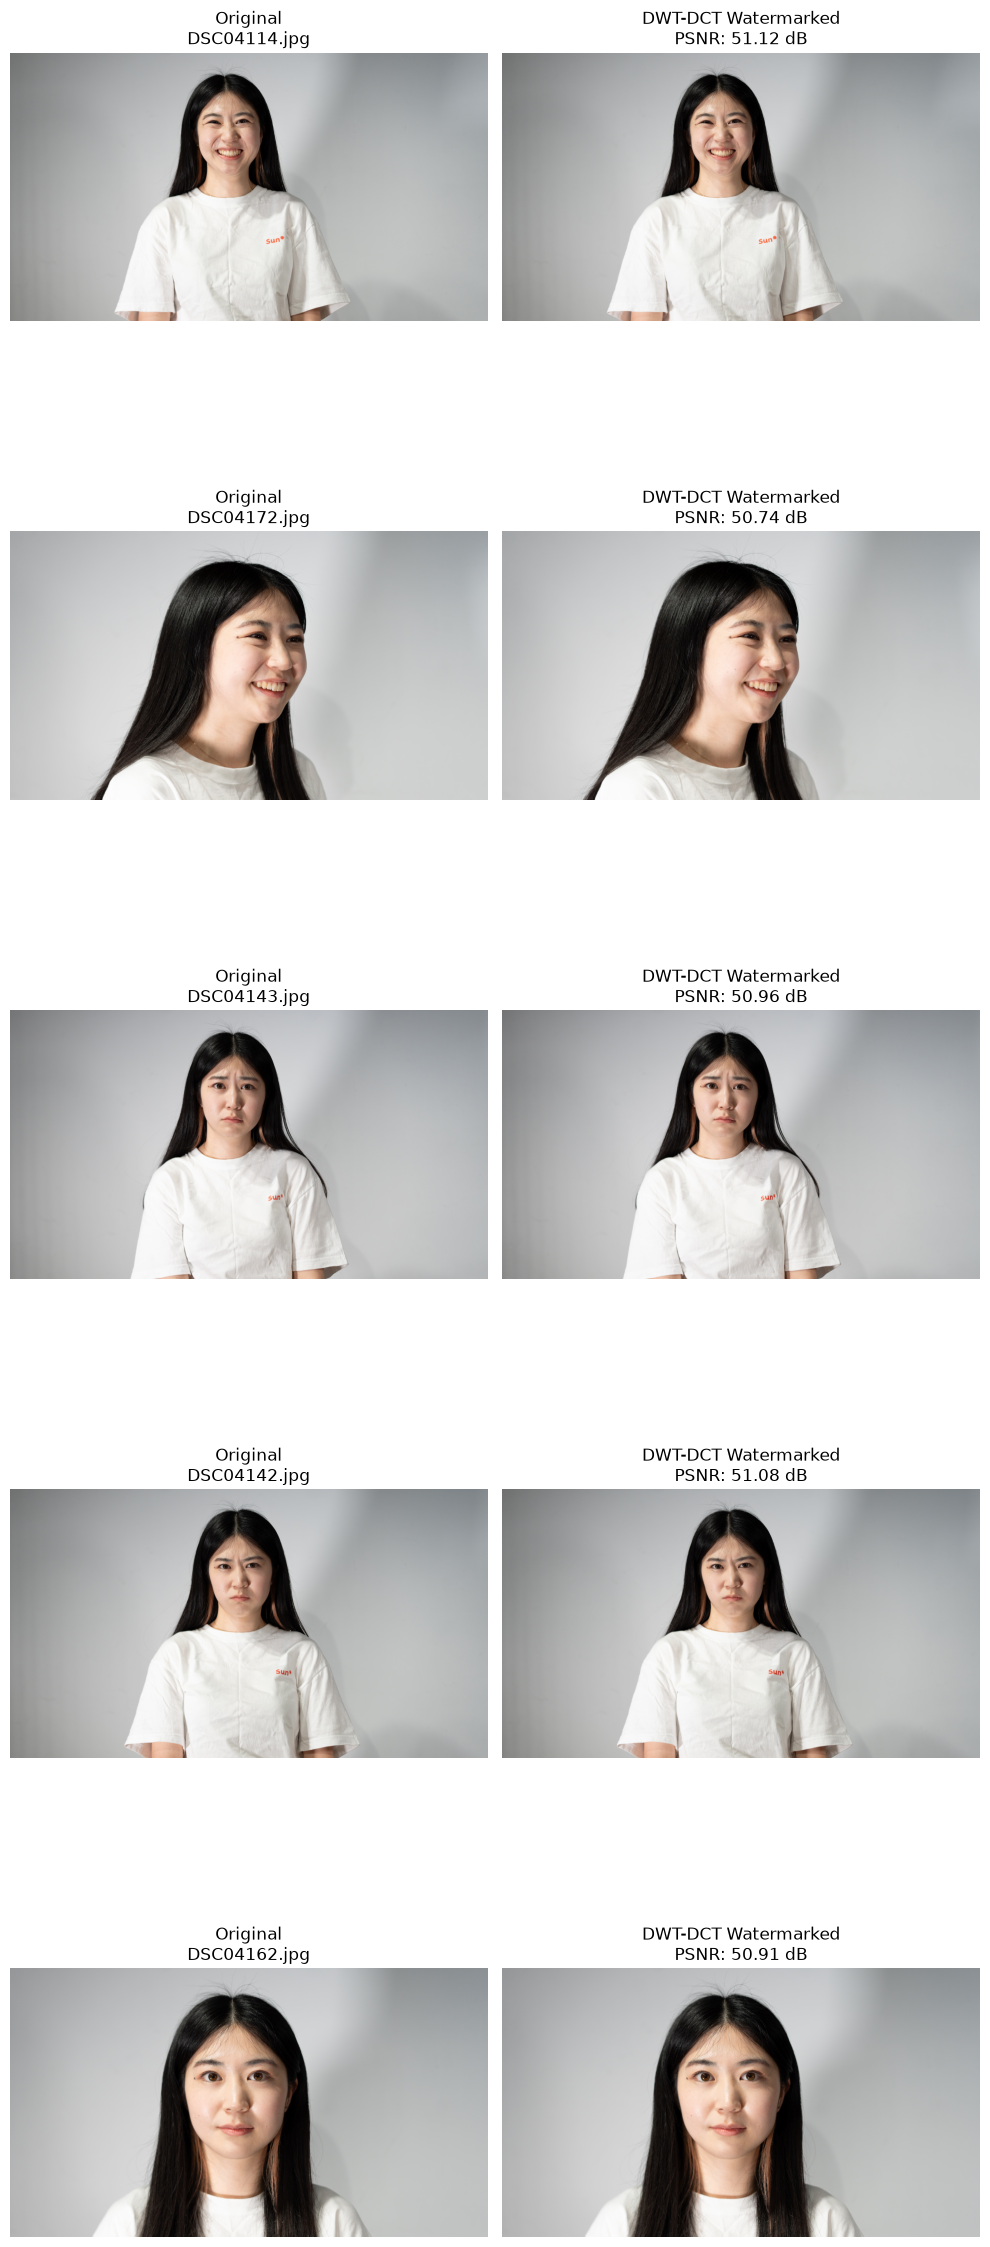

In [154]:
fig, axes = plt.subplots(
    nrows=len(results),
    ncols=2,
    figsize=(10, 5 * len(results))
)

for i, result in enumerate(results):

    original_rgb = cv2.cvtColor(
        result["original"],
        cv2.COLOR_BGR2RGB
    )

    watermarked_rgb = cv2.cvtColor(
        result["watermarked"],
        cv2.COLOR_BGR2RGB
    )

    axes[i, 0].imshow(original_rgb)
    axes[i, 0].set_title(
        f"Original\n{result['path'].name}"
    )
    axes[i, 0].axis("off")

    axes[i, 1].imshow(watermarked_rgb)
    axes[i, 1].set_title(
        f"DWT-DCT Watermarked\n"
        f"PSNR: {result['psnr']:.2f} dB"
    )
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

# ATTACK

In [155]:
decoded_bits = watermarker.extract_bits(
    result["watermarked"],
    len(watermark_bits)
)

decoded_bits_long = watermarker.extract_bits(
    result["watermarked"],
    len(watermark_bits_long)
)

In [156]:
def calculate_ber(original_bits, decoded_bits):
    """
    Calculate Bit Error Rate (BER).

    BER = number of incorrect bits / total number of bits
    """

    original_bits = np.asarray(original_bits).flatten()
    decoded_bits = np.asarray(decoded_bits).flatten()

    if len(original_bits) != len(decoded_bits):
        raise ValueError(
            f"Bit length mismatch: "
            f"{len(original_bits)} vs {len(decoded_bits)}"
        )

    return np.mean(original_bits != decoded_bits)

In [157]:
def attack_jpeg(image, quality=50):
    """
    JPEG encode/decode attack.
    """
    encode_params = [
        cv2.IMWRITE_JPEG_QUALITY,
        quality
    ]

    success, encoded = cv2.imencode(
        ".jpg",
        image,
        encode_params
    )

    if not success:
        raise RuntimeError("JPEG encoding failed.")

    return cv2.imdecode(
        encoded,
        cv2.IMREAD_COLOR
    )


def attack_resize(image, scale=0.5):
    """
    Downscale and then upscale back to original dimensions.
    """
    h, w = image.shape[:2]

    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))

    downscaled = cv2.resize(
        image,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )

    restored = cv2.resize(
        downscaled,
        (w, h),
        interpolation=cv2.INTER_LINEAR
    )

    return restored


def attack_gaussian_noise(image, sigma=5.0):
    """
    Add Gaussian noise to the image.
    """
    noise = np.random.normal(
        0,
        sigma,
        image.shape
    )

    noisy = image.astype(np.float32) + noise

    return np.clip(
        noisy,
        0,
        255
    ).astype(np.uint8)


def attack_crop(image, crop_ratio=0.8):
    """
    Center crop the image and resize it back to
    the original dimensions.
    """
    h, w = image.shape[:2]

    crop_h = int(h * crop_ratio)
    crop_w = int(w * crop_ratio)

    y0 = (h - crop_h) // 2
    x0 = (w - crop_w) // 2

    cropped = image[
        y0:y0 + crop_h,
        x0:x0 + crop_w
    ]

    restored = cv2.resize(
        cropped,
        (w, h),
        interpolation=cv2.INTER_LINEAR
    )

    return restored

In [158]:
attacks = {
    "JPEG Q50": lambda img: attack_jpeg(img, quality=50),
    "JPEG Q30": lambda img: attack_jpeg(img, quality=30),
    "Resize 50%": lambda img: attack_resize(img, scale=0.5),
    "Noise σ=5": lambda img: attack_gaussian_noise(img, sigma=5),
    "Crop 80%": lambda img: attack_crop(img, crop_ratio=0.8),
}

In [159]:
attack_results = {}

for attack_name, attack_fn in attacks.items():

    print(f"\n===== {attack_name} =====")

    attack_results[attack_name] = []

    for i, result in enumerate(results):

        watermarked = result["watermarked"]

        # Apply attack
        attacked = attack_fn(watermarked)

        # Recover watermark
        decoded_bits = watermarker.extract_bits(
            attacked,
            len(watermark_bits)
        )

        # Calculate BER
        ber = calculate_ber(
            watermark_bits,
            decoded_bits
        )

        # Image preservation
        psnr = calculate_psnr(
            result["original"],
            attacked
        )

        attack_results[attack_name].append({
            "image": result["path"].name,
            "attacked": attacked,
            "ber": ber,
            "psnr": psnr,
        })

        print(
            f"{result['path'].name:30s} "
            f"BER={ber:.4f}  "
            f"PSNR={psnr:.2f} dB"
        )


===== JPEG Q50 =====
DSC04114.jpg                   BER=0.3929  PSNR=35.61 dB
DSC04172.jpg                   BER=0.4000  PSNR=35.95 dB
DSC04143.jpg                   BER=0.3893  PSNR=35.78 dB
DSC04142.jpg                   BER=0.3357  PSNR=35.61 dB
DSC04162.jpg                   BER=0.4036  PSNR=35.88 dB

===== JPEG Q30 =====
DSC04114.jpg                   BER=0.4571  PSNR=34.67 dB
DSC04172.jpg                   BER=0.4643  PSNR=34.97 dB
DSC04143.jpg                   BER=0.4536  PSNR=34.83 dB
DSC04142.jpg                   BER=0.4536  PSNR=34.66 dB
DSC04162.jpg                   BER=0.4107  PSNR=34.94 dB

===== Resize 50% =====
DSC04114.jpg                   BER=0.4857  PSNR=36.13 dB
DSC04172.jpg                   BER=0.4643  PSNR=36.06 dB
DSC04143.jpg                   BER=0.4679  PSNR=36.28 dB
DSC04142.jpg                   BER=0.5464  PSNR=36.06 dB
DSC04162.jpg                   BER=0.4964  PSNR=36.24 dB

===== Noise σ=5 =====
DSC04114.jpg                   BER=0.0393  PSNR=33.96 

In [160]:
attack_results_long = {}

for attack_name, attack_fn in attacks.items():

    print(f"\n===== {attack_name} =====")

    attack_results_long[attack_name] = []

    for i, result in enumerate(results_long):

        watermarked_long = result["watermarked"]

        # Apply attack
        attacked = attack_fn(watermarked_long)

        # Recover watermark
        decoded_bits_long = watermarker.extract_bits(
            attacked,
            len(watermark_bits_long)
        )

        # Calculate BER
        ber = calculate_ber(
            watermark_bits_long,
            decoded_bits_long
        )

        # Image preservation
        psnr = calculate_psnr(
            result["original"],
            attacked
        )

        attack_results_long[attack_name].append({
            "image": result["path"].name,
            "attacked": attacked,
            "ber": ber,
            "psnr": psnr,
        })

        print(
            f"{result['path'].name:30s} "
            f"BER={ber:.4f}  "
            f"PSNR={psnr:.2f} dB"
        )


===== JPEG Q50 =====
DSC04114.jpg                   BER=0.3713  PSNR=35.61 dB
DSC04172.jpg                   BER=0.3840  PSNR=35.95 dB
DSC04143.jpg                   BER=0.3721  PSNR=35.78 dB
DSC04142.jpg                   BER=0.3733  PSNR=35.61 dB
DSC04162.jpg                   BER=0.3729  PSNR=35.88 dB

===== JPEG Q30 =====
DSC04114.jpg                   BER=0.4346  PSNR=34.67 dB
DSC04172.jpg                   BER=0.4362  PSNR=34.97 dB
DSC04143.jpg                   BER=0.4339  PSNR=34.83 dB
DSC04142.jpg                   BER=0.4345  PSNR=34.66 dB
DSC04162.jpg                   BER=0.4399  PSNR=34.94 dB

===== Resize 50% =====
DSC04114.jpg                   BER=0.5044  PSNR=36.13 dB
DSC04172.jpg                   BER=0.4990  PSNR=36.07 dB
DSC04143.jpg                   BER=0.5010  PSNR=36.28 dB
DSC04142.jpg                   BER=0.5056  PSNR=36.06 dB
DSC04162.jpg                   BER=0.4957  PSNR=36.24 dB

===== Noise σ=5 =====
DSC04114.jpg                   BER=0.0239  PSNR=33.95 

In [161]:
for attack_name, attack_data in attack_results.items():

    mean_ber = np.mean([
        x["ber"]
        for x in attack_data
    ])

    mean_psnr = np.mean([
        x["psnr"]
        for x in attack_data
    ])

    print(
        f"{attack_name:15s} | "
        f"Mean BER: {mean_ber:.4f} | "
        f"Mean PSNR: {mean_psnr:.2f} dB"
    )

JPEG Q50        | Mean BER: 0.3843 | Mean PSNR: 35.77 dB
JPEG Q30        | Mean BER: 0.4479 | Mean PSNR: 34.81 dB
Resize 50%      | Mean BER: 0.4921 | Mean PSNR: 36.16 dB
Noise σ=5       | Mean BER: 0.0236 | Mean PSNR: 33.97 dB
Crop 80%        | Mean BER: 0.5407 | Mean PSNR: 13.50 dB


In [162]:
for attack_name, attack_data in attack_results_long.items():

    mean_ber = np.mean([
        x["ber"]
        for x in attack_data
    ])

    mean_psnr = np.mean([
        x["psnr"]
        for x in attack_data
    ])

    print(
        f"{attack_name:15s} | "
        f"Mean BER: {mean_ber:.4f} | "
        f"Mean PSNR: {mean_psnr:.2f} dB"
    )

JPEG Q50        | Mean BER: 0.3747 | Mean PSNR: 35.77 dB
JPEG Q30        | Mean BER: 0.4358 | Mean PSNR: 34.81 dB
Resize 50%      | Mean BER: 0.5012 | Mean PSNR: 36.16 dB
Noise σ=5       | Mean BER: 0.0234 | Mean PSNR: 33.96 dB
Crop 80%        | Mean BER: 0.5019 | Mean PSNR: 13.50 dB


In [ ]:
# import torch
# import torch.nn
# import argparse
# import os
# import numpy as np
# from options import HiDDenConfiguration

# import utils
# from model.hidden import *
# from noise_layers.noiser import Noiser
# from PIL import Image
# import torchvision.transforms.functional as TF


# def centerCrop(img, height, width):
#     assert img.shape[0] >= height
#     assert img.shape[1] >= width

#     x = (img.shape[1] - width) // 2
#     y = (img.shape[0] - height) // 2

#     return img[y:y+height, x:x+width]


# def main():
#     if torch.cuda.is_available():
#         device = torch.device('cuda')
#     else:
#         device = torch.device('cpu')

#     parser = argparse.ArgumentParser(description='Test trained models')
#     parser.add_argument('--options-file', '-o', default='options-and-config.pickle', type=str,
#                         help='The file where the simulation options are stored.')
#     parser.add_argument('--checkpoint-file', '-c', required=True, type=str, help='Model checkpoint file')
#     parser.add_argument('--batch-size', '-b', default=10, type=int, help='The batch size.')
#     parser.add_argument('--source-image', '-s', required=True, type=str,
#                         help='The image to watermark')
#     parser.add_argument(
#         '--message',
#         '-m',
#         type=str,
#         default = "010100110100000100101010000000",
#         help='Binary watermark message'
#     )
#     # parser.add_argument('--times', '-t', default=10, type=int,
#     #                     help='Number iterations (insert watermark->extract).')

#     args = parser.parse_args()

#     train_options, hidden_config, noise_config = utils.load_options(args.options_file)
#     noiser = Noiser(noise_config, device)

#     checkpoint = torch.load(args.checkpoint_file)
#     hidden_net = Hidden(hidden_config, device, noiser, None)
#     utils.model_from_checkpoint(hidden_net, checkpoint)


#     image_pil = Image.open(args.source_image)
#     image = centerCrop(np.array(image_pil), hidden_config.H, hidden_config.W)
#     image_tensor = TF.to_tensor(image).to(device)
#     image_tensor = image_tensor * 2 - 1  # transform from [0, 1] to [-1, 1]
#     image_tensor.unsqueeze_(0)

#     # for t in range(args.times):
#     message = torch.tensor(
#         [[float(bit) for bit in args.message]],
#         dtype=torch.float32,
#         device=device
#     )
#     losses, (encoded_images, noised_images, decoded_messages) = hidden_net.validate_on_batch([image_tensor, message])
#     print('attack : {}'.format(noiser.last_noise_layer))
#     decoded_rounded = decoded_messages.detach().cpu().numpy().round().clip(0, 1)
#     message_detached = message.detach().cpu().numpy()
#     print('original: {}'.format(message_detached))
#     print('decoded : {}'.format(decoded_rounded))
#     print('error : {:.3f}'.format(np.mean(np.abs(decoded_rounded - message_detached))))
#     utils.save_images(image_tensor.cpu(), encoded_images.cpu(), 'test', '.', resize_to=(256, 256))

#     # bitwise_avg_err = np.sum(np.abs(decoded_rounded - message.detach().cpu().numpy()))/(image_tensor.shape[0] * messages.shape[1])



# if __name__ == '__main__':
#     main()


usage: ipykernel_launcher.py [-h] [--options-file OPTIONS_FILE]
                             --checkpoint-file CHECKPOINT_FILE
                             [--batch-size BATCH_SIZE] --source-image
                             SOURCE_IMAGE [--message MESSAGE]
ipykernel_launcher.py: error: the following arguments are required: --checkpoint-file/-c, --source-image/-s


SystemExit: 2

/home/trinh.minh.hieu/miniconda3/envs/hidden/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3783: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
# from pathlib import Path

# ROOT = Path("./dataset/image_30k")
# EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# total = 0

# for split in ["train", "val", "test"]:
#     split_dir = ROOT / split

#     images = [
#         p for p in split_dir.rglob("*")
#         if p.is_file() and p.suffix.lower() in EXTENSIONS
#     ]

#     count = len(images)
#     total += count

#     print(f"{split:>5}: {count:,} images")

# print("-" * 25)
# print(f"total: {total:,} images")

train: 24,000 images
  val: 3,000 images
 test: 3,000 images
-------------------------
total: 30,000 images


In [ ]:
# from pathlib import Path
# from PIL import Image

# # Mother folder containing train/, val/, test/
# DATASET_DIR = Path("./dataset")

# SPLITS = ["train", "val", "test"]
# TARGET_SIZE = (128, 128)

# IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

# total = 0

# for split in SPLITS:
#     split_dir = DATASET_DIR / split

#     if not split_dir.exists():
#         print(f"[WARNING] Missing: {split_dir}")
#         continue

#     print(f"\nProcessing {split}...")

#     for image_path in split_dir.rglob("*"):
#         if not image_path.is_file():
#             continue

#         if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
#             continue

#         try:
#             with Image.open(image_path) as img:
#                 # Convert to RGB so PNG/RGBA/etc. don't cause surprises
#                 if img.mode not in ("RGB", "L"):
#                     img = img.convert("RGB")

#                 resized = img.resize(
#                     TARGET_SIZE,
#                     Image.Resampling.LANCZOS
#                 )

#                 # Overwrite original file
#                 resized.save(image_path)

#             total += 1

#             if total % 500 == 0:
#                 print(f"Processed {total} images...")

#         except Exception as e:
#             print(f"[ERROR] {image_path}: {e}")

# print(f"\nDone. Resized {total} images to 128x128.")


Processing train...
Processed 500 images...
Processed 1000 images...
Processed 1500 images...
Processed 2000 images...
Processed 2500 images...
Processed 3000 images...
Processed 3500 images...
Processed 4000 images...
Processed 4500 images...
Processed 5000 images...
Processed 5500 images...
Processed 6000 images...
Processed 6500 images...
Processed 7000 images...
Processed 7500 images...
Processed 8000 images...

Processing val...
Processed 8500 images...
Processed 9000 images...

Processing test...
Processed 9500 images...
Processed 10000 images...

Done. Resized 10000 images to 128x128.
